# Visualize ETC 2D Combined Data

This notebook demonstrates how to visualize combined ETC 2D extraction data with multiple overlay features including:
- Shaded variables (e.g., relative humidity)
- Contour lines (e.g., geopotential height)
- Wind vectors
- MCS mask outlines (multi-colored)
- AR mask outlines (dark orange)

**Combined data produced by:**: `combine_etc_2d_vars.py`

**Data Source**: `/pscratch/sd/w/wcmca1/hackathon/etc_data/tests/scream_ne120_inst/etc_2d_combined_track1014.zarr`

## 1. Import Required Libraries

In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from scipy.ndimage import gaussian_filter
import pandas as pd
import colormaps as cmaps
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

# Set matplotlib defaults for better-looking plots
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Read the Combined ETC Data

In [2]:
# Path to the combined zarr file
zarr_path = "/pscratch/sd/w/wcmca1/hackathon/etc_data/tests/scream_ne120_inst/etc_2d_combined_track1014.zarr"
# Figure directory
figdir = "/global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_etc/"
os.makedirs(figdir, exist_ok=True)

# Open the zarr dataset
print(f"Opening zarr file: {zarr_path}")
ds = xr.open_zarr(zarr_path)

print(f"\nDataset loaded successfully!")
print(f"Number of time steps: {len(ds.time)}")
print(f"Grid dimensions: {len(ds.y)} × {len(ds.x)}")

Opening zarr file: /pscratch/sd/w/wcmca1/hackathon/etc_data/tests/scream_ne120_inst/etc_2d_combined_track1014.zarr

Dataset loaded successfully!
Number of time steps: 17
Grid dimensions: 161 × 161

Dataset loaded successfully!
Number of time steps: 17
Grid dimensions: 161 × 161


In [3]:
# Select a specific ETC track
storm_ID = 1014
# Subset DataSet with the storm_ID
storm_id = ds.storm_id.compute()
ds = ds.where(storm_id == storm_ID, drop=True)

## 3. Explore the Dataset Structure

In [4]:
# Display dataset information
print("Dataset Dimensions:")
print(ds.dims)
print("\n" + "="*60)

print("\nDataset Coordinates:")
print(ds.coords)
print("\n" + "="*60)

print("\nData Variables:")
for var in ds.data_vars:
    print(f"  {var}: {ds[var].dims} - {ds[var].shape}")
print("\n" + "="*60)

print("\nDataset Attributes:")
for key, val in ds.attrs.items():
    print(f"  {key}: {val}")

Dataset Dimensions:
FrozenMappingWarningOnValuesAccess({'time': 17, 'y': 161, 'x': 161})


Dataset Coordinates:
Coordinates:
  * time     (time) datetime64[ns] 136B 2020-05-20T18:00:00 ... 2020-05-24T18...
  * x        (x) int64 1kB -80 -79 -78 -77 -76 -75 -74 ... 74 75 76 77 78 79 80
  * y        (y) int64 1kB -80 -79 -78 -77 -76 -75 -74 ... 74 75 76 77 78 79 80


Data Variables:
  ar_mcs_etc_overlap_mask: ('time', 'y', 'x') - (17, 161, 161)
  etc_mcs_ar_overlap_mask: ('time', 'y', 'x') - (17, 161, 161)
  grid_id: ('time',) - (17,)
  mcs_ar_etc_overlap_mask: ('time', 'y', 'x') - (17, 161, 161)
  pr: ('time', 'y', 'x') - (17, 161, 161)
  psl: ('time', 'y', 'x') - (17, 161, 161)
  rh850: ('time', 'y', 'x') - (17, 161, 161)
  storm_id: ('time',) - (17,)
  storm_lat: ('time',) - (17,)
  storm_lon: ('time',) - (17,)
  ua500: ('time', 'y', 'x') - (17, 161, 161)
  ua850: ('time', 'y', 'x') - (17, 161, 161)
  uivt: ('time', 'y', 'x') - (17, 161, 161)
  va500: ('time', 'y', 'x') - (17, 161, 16

## 4. Create Plotting Function

This function creates a comprehensive visualization with:
- **Shaded variable**: Filled contours (e.g., relative humidity)
- **Contour variable**: Black contour lines (e.g., geopotential height)
- **Vector fields**: Wind vectors with adjustable density
- **MCS mask outlines**: Multi-colored outlines for each MCS track
- **AR mask outlines**: Dark orange outline for atmospheric rivers

In [5]:
def plot_etc_snapshot(ds, time_idx, 
                      shade_var='rh850', shade_levels=None, shade_cmap='RdBu_r', shade_scale=1.0, shade_alpha=1.0,
                      shade_label=None,
                      shade_var2=None, shade_levels2=None, shade_cmap2='YlGnBu', shade_scale2=1.0, shade_alpha2=0.7,
                      shade_label2=None,
                      contour_var='zg500', contour_levels=None, contour_smooth=0, contour_lw=1.0,
                      u_var='ua850', v_var='va850', vector_skip=3,
                      plot_mcs_mask=True, mcs_mask_outline=True, mcs_mask_alpha=0.3,
                      plot_ar_mask=True, ar_mask_outline=True, ar_mask_alpha=0.3,
                      circle_radius=None,
                      xlim=None, ylim=None,
                      xlabel=None, ylabel=None,
                      figsize=(12, 10), dpi=100, figname=None):
    """
    Plot a single time snapshot of ETC data with multiple overlays.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        The combined ETC dataset
    time_idx : int
        Time index to plot
    shade_var : str
        Variable name for shaded contours (default: 'rh850')
    shade_levels : array-like or None
        Contour levels for shading (default: auto)
    shade_cmap : str
        Colormap for shaded variable (default: 'RdBu_r')
    shade_scale : float
        Scale factor for shaded variable (default: 1.0)
        e.g., use 100 to convert 0-1 to 0-100 (fraction to percentage)
    shade_alpha : float
        Transparency for shaded variable (default: 1.0, range: 0-1)
    shade_label : str or None
        Custom label for first shaded variable colorbar (default: None, auto-generate)
    shade_var2 : str or None
        Second variable to shade/overplot (default: None, e.g., 'pr')
    shade_levels2 : array-like or None
        Contour levels for second shading (default: auto)
    shade_cmap2 : str
        Colormap for second shaded variable (default: 'YlGnBu')
    shade_scale2 : float
        Scale factor for second shaded variable (default: 1.0)
    shade_alpha2 : float
        Transparency for second shaded variable (default: 0.7)
    shade_label2 : str or None
        Custom label for second shaded variable colorbar (default: None, auto-generate)
    contour_var : str
        Variable name for line contours (default: 'zg500')
    contour_levels : array-like or None
        Contour levels for lines (default: auto)
    contour_smooth : int
        Smoothing sigma for contour variable using Gaussian filter (default: 0, no smoothing)
        Higher values = more smoothing (e.g., 2-5 for moderate smoothing)
    contour_lw : float
        Contour line width. (default: 1.0)
    u_var : str
        U-component of wind (default: 'ua850')
    v_var : str
        V-component of wind (default: 'va850')
    vector_skip : int
        Skip every N points for vectors (default: 3)
    plot_mcs_mask : bool
        Whether to plot MCS mask (default: True)
    mcs_mask_outline : bool
        If True, plot MCS mask as outlines; if False, use pcolormesh shading (default: True)
    mcs_mask_alpha : float
        Transparency for MCS mask when using pcolormesh (default: 0.3)
    plot_ar_mask : bool
        Whether to plot AR mask (default: True)
    ar_mask_outline : bool
        If True, plot AR mask as outline; if False, use pcolormesh shading (default: True)
    ar_mask_alpha : float
        Transparency for AR mask when using pcolormesh (default: 0.3)
    circle_radius : float or None
        Radius of circle in degrees. If None, no circle is plotted (default: None)
    xlim : tuple or None
        X-axis limits in degrees (e.g., (-15, 15)). If None, use full range (default: None)
    ylim : tuple or None
        Y-axis limits in degrees (e.g., (-15, 15)). If None, use full range (default: None)
    xlabel : str or None
        Custom x-axis label (default: None, auto-generate)
    ylabel : str or None
        Custom y-axis label (default: None, auto-generate)
    figsize : tuple
        Figure size (default: (14, 10))
    dpi : int
        Figure DPI (default: 100)
    figname: str
        Figure name for saving (optional).
    
    Returns:
    --------
    fig : matplotlib figure object
    """
    
    # Extract data for this time step
    data_time = ds.isel(time=time_idx)
    
    # Get coordinates and convert to degrees
    lat_res = ds.attrs.get('lat_res', 0.25)
    lon_res = ds.attrs.get('lon_res', 0.25)
    
    x = data_time.x.values * lon_res
    y = data_time.y.values * lat_res
    X, Y = np.meshgrid(x, y)
    
    # Get metadata
    storm_id = int(data_time.storm_id.values)
    timestamp = pd.Timestamp(data_time.time.values)
    storm_lat = float(data_time.storm_lat.values)
    storm_lon = float(data_time.storm_lon.values)
    
    # Create figure with GridSpec for better colorbar control
    fig = plt.figure(figsize=figsize, dpi=dpi)
    
    # Determine number of colorbars needed
    has_shade_var2 = shade_var2 is not None and shade_var2 in ds
    
    if has_shade_var2:
        # Create main GridSpec: [plot | colorbars]
        gs_main = gridspec.GridSpec(1, 2, figure=fig, 
                                   width_ratios=[1, 0.15],
                                   wspace=0.05)  # Small gap between plot and colorbar area
        
        # Create subplot for the main plot
        ax = fig.add_subplot(gs_main[0])
        
        # Create nested GridSpec for the two colorbars
        gs_cbar = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[1],
                                                   width_ratios=[0.005, 0.005],
                                                   wspace=4)  # Gap between two colorbars
        cax1 = fig.add_subplot(gs_cbar[0])
        cax2 = fig.add_subplot(gs_cbar[1])
    else:
        # Create GridSpec: [main plot | cbar1]
        gs_main = gridspec.GridSpec(1, 2, figure=fig,
                                   width_ratios=[1, 0.04],
                                   wspace=0.02)  # Small gap between plot and colorbar
        ax = fig.add_subplot(gs_main[0])
        cax1 = fig.add_subplot(gs_main[1])
        cax2 = None
    
    # ===== 1. FIRST SHADED VARIABLE (z_order=0) =====
    if shade_var in ds:
        shade_data = data_time[shade_var].values * shade_scale
        
        if shade_levels is None:
            # Auto-generate levels
            vmin, vmax = np.nanpercentile(shade_data, [2, 98])
            shade_levels = np.linspace(vmin, vmax, 20)
        
        # Use contourf without contour lines
        cf = ax.contourf(X, Y, shade_data, levels=shade_levels,
                        cmap=shade_cmap, extend='both', alpha=shade_alpha, 
                        antialiased=True, zorder=0)
        cbar = plt.colorbar(cf, cax=cax1, orientation='vertical')
        
        # Generate colorbar label
        if shade_label is not None:
            cbar_label = shade_label
        else:
            cbar_label = f'{shade_var}'
            if shade_scale != 1.0:
                cbar_label += f' (×{shade_scale})'
        cbar.set_label(cbar_label)
    
    # ===== 2. SECOND SHADED VARIABLE (OVERPLOT) (z_order=3) =====
    if shade_var2 is not None and shade_var2 in ds:
        shade_data2 = data_time[shade_var2].values * shade_scale2
        if shade_levels2 is None:
            # Auto-generate levels
            vmin2, vmax2 = np.nanpercentile(shade_data2, [2, 98])
            shade_levels2 = np.linspace(vmin2, vmax2, 20)
        # Mask values < min(shade_levels2)
        shade_data2 = np.ma.masked_where(shade_data2 < np.min(shade_levels2), shade_data2)
        
        # Use contourf without contour lines
        cf2 = ax.contourf(X, Y, shade_data2, levels=shade_levels2,
                         cmap=shade_cmap2, extend='both', alpha=shade_alpha2,
                         antialiased=True, zorder=3)
        
        # Add second colorbar to the dedicated axis
        if cax2 is not None:
            cbar2 = plt.colorbar(cf2, cax=cax2, orientation='vertical')
            
            # Generate colorbar label
            if shade_label2 is not None:
                cbar_label2 = shade_label2
            else:
                cbar_label2 = f'{shade_var2}'
                if shade_scale2 != 1.0:
                    cbar_label2 += f' (×{shade_scale2})'
            cbar2.set_label(cbar_label2)
    
    # ===== 3. CONTOUR VARIABLE (z_order=4) =====
    if contour_var in ds:
        contour_data = data_time[contour_var].values
        
        # Apply smoothing if requested
        if contour_smooth > 0:
            contour_data = gaussian_filter(contour_data, sigma=contour_smooth)
        
        if contour_levels is None:
            # Auto-generate levels
            vmin, vmax = np.nanpercentile(contour_data, [5, 95])
            contour_levels = np.linspace(vmin, vmax, 10)
        
        cs = ax.contour(X, Y, contour_data, levels=contour_levels, 
                       colors='black', linewidths=contour_lw, alpha=0.6, zorder=4)
        ax.clabel(cs, inline=True, fontsize=8, fmt='%.0f')
    
    # ===== 4. WIND VECTORS (z_order=5) =====
    if u_var in ds and v_var in ds:
        u_data = data_time[u_var].values
        v_data = data_time[v_var].values
        
        # Subsample for vector plotting
        X_sub = X[::vector_skip, ::vector_skip]
        Y_sub = Y[::vector_skip, ::vector_skip]
        u_sub = u_data[::vector_skip, ::vector_skip]
        v_sub = v_data[::vector_skip, ::vector_skip]
        
        # Plot vectors
        Q = ax.quiver(X_sub, Y_sub, u_sub, v_sub, 
                     color='black', alpha=0.7, scale=300, width=0.003, zorder=5)
        # Add quiver key
        ax.quiverkey(Q, 0.9, 1.02, 10, '10 m/s', labelpos='E', coordinates='axes')
    
    # ===== 5. AR MASK (z_order=1) =====
    ar_binary = np.zeros_like(X)
    if plot_ar_mask and 'ar_mcs_etc_overlap_mask' in ds:
        ar_mask = data_time['ar_mcs_etc_overlap_mask'].values
        
        # Create binary mask (any non-zero value is AR)
        ar_binary = (ar_mask > 0).astype(float)
        
        if np.any(ar_binary):
            if ar_mask_outline:
                # Contour the AR outline in dark orange
                ax.contour(X, Y, ar_binary, levels=[0.5], 
                          colors=['darkorange'], linewidths=3.0, alpha=0.9,
                          linestyles='solid', zorder=1)
            else:
                # Plot as pcolormesh shading in dark orange
                ar_mask_plot = np.ma.masked_where(ar_binary == 0, ar_binary)
                ax.pcolormesh(X, Y, ar_mask_plot, cmap='Oranges', 
                             shading='auto', alpha=ar_mask_alpha, rasterized=True,
                             vmin=0, vmax=2, zorder=1)  # Adjust vmax for darker orange
    
    # ===== 6. MCS MASK (z_order=2) =====
    mcs_ids = np.array([])
    if plot_mcs_mask and 'mcs_ar_etc_overlap_mask' in ds:
        mcs_mask = data_time['mcs_ar_etc_overlap_mask'].values
        
        # Get unique MCS IDs (excluding 0 = background)
        mcs_ids = np.unique(mcs_mask[mcs_mask > 0])
        
        if len(mcs_ids) > 0:
            if mcs_mask_outline:
                # Plot as multi-colored outlines
                tab20 = cm.get_cmap('tab20', 20)
                
                for i, mcs_id in enumerate(mcs_ids):
                    # Create binary mask for this MCS
                    binary_mask = (mcs_mask == mcs_id).astype(float)
                    
                    # Find contours at 0.5 level (boundary)
                    color = tab20(i % 20)
                    ax.contour(X, Y, binary_mask, levels=[0.5], 
                              colors=[color], linewidths=2.5, alpha=0.9, zorder=2)
            else:
                # Plot as pcolormesh shading using a specified color
                # Create a custom colormap for values > 0
                mcs_shade_color = 'limegreen'
                mcs_cmap = ListedColormap([mcs_shade_color])
                mcs_mask_plot = np.ma.masked_where(mcs_mask == 0, mcs_mask)
                ax.pcolormesh(X, Y, mcs_mask_plot, cmap=mcs_cmap, 
                             shading='auto', alpha=mcs_mask_alpha, rasterized=True, zorder=2)
    
    # ===== 7. LABELS AND FORMATTING =====
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    else:
        ax.set_xlabel('x (degrees from storm center)')
    
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    else:
        ax.set_ylabel('y (degrees from storm center)')
    
    # Title with ETC track number and datetime
    title = f'ETC Track {storm_id}\n{timestamp.strftime("%Y-%m-%d %H:%M UTC")}'
    title += f'\nStorm Center: {storm_lat:.2f}°N, {storm_lon:.2f}°E'
    ax.set_title(title, fontweight='bold')
    
    # Add gridlines
    ax.grid(True, alpha=0.5, linestyle=':', linewidth=0.5, zorder=10)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1, zorder=10)
    ax.axvline(x=0, color='k', linestyle='--', linewidth=1, zorder=10)
    
    # Set aspect ratio to equal
    # ax.set_aspect('equal')
    
    # Set x, y limits if specified
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    
    # Add legend for mask outlines

    legend_elements = []
    if plot_mcs_mask and len(mcs_ids) > 0:
        if mcs_mask_outline:
            legend_elements.append(Line2D([0], [0], color='gray', linewidth=2.5, 
                                         label='MCS outlines (multi-color)'))
        else:
            legend_elements.append(Patch(facecolor=mcs_shade_color, alpha=mcs_mask_alpha, 
                                        label='MCS (shaded)'))
    if plot_ar_mask and np.any(ar_binary):
        if ar_mask_outline:
            legend_elements.append(Line2D([0], [0], color='darkorange', linewidth=3.0, 
                                         label='AR outline'))
        else:
            legend_elements.append(Patch(facecolor='darkorange', alpha=ar_mask_alpha, 
                                        label='AR (shaded)'))
    
    if legend_elements:
        ax.legend(handles=legend_elements, loc='upper left')
    
    # ===== 8. CIRCLE (z_order=8) =====
    if circle_radius is not None:
        circle = plt.Circle((0, 0), circle_radius, fill=False, 
                           edgecolor='purple', linewidth=4, alpha=0.7, zorder=8)
        ax.add_patch(circle)
    
    # Save figure if directory is provided
    if figname:
        plt.savefig(figname, dpi=dpi, bbox_inches='tight')
        print(f'Figure saved: {figname}')
    
    return fig

print("Plotting function defined successfully!")


Plotting function defined successfully!


## 5. Test the Plotting Function

Let's create a visualization with the following settings:
- **Shading**: Relative humidity at 850 hPa (rh850)
- **Contours**: Geopotential height at 500 hPa (zg500)
- **Vectors**: Winds at 850 hPa (ua850, va850)

Plotting time index: 3 / 17
Timestamp: 2020-05-21 12:00:00
Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_etc/etc_20200521_1200.png
Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_etc/etc_20200521_1200.png


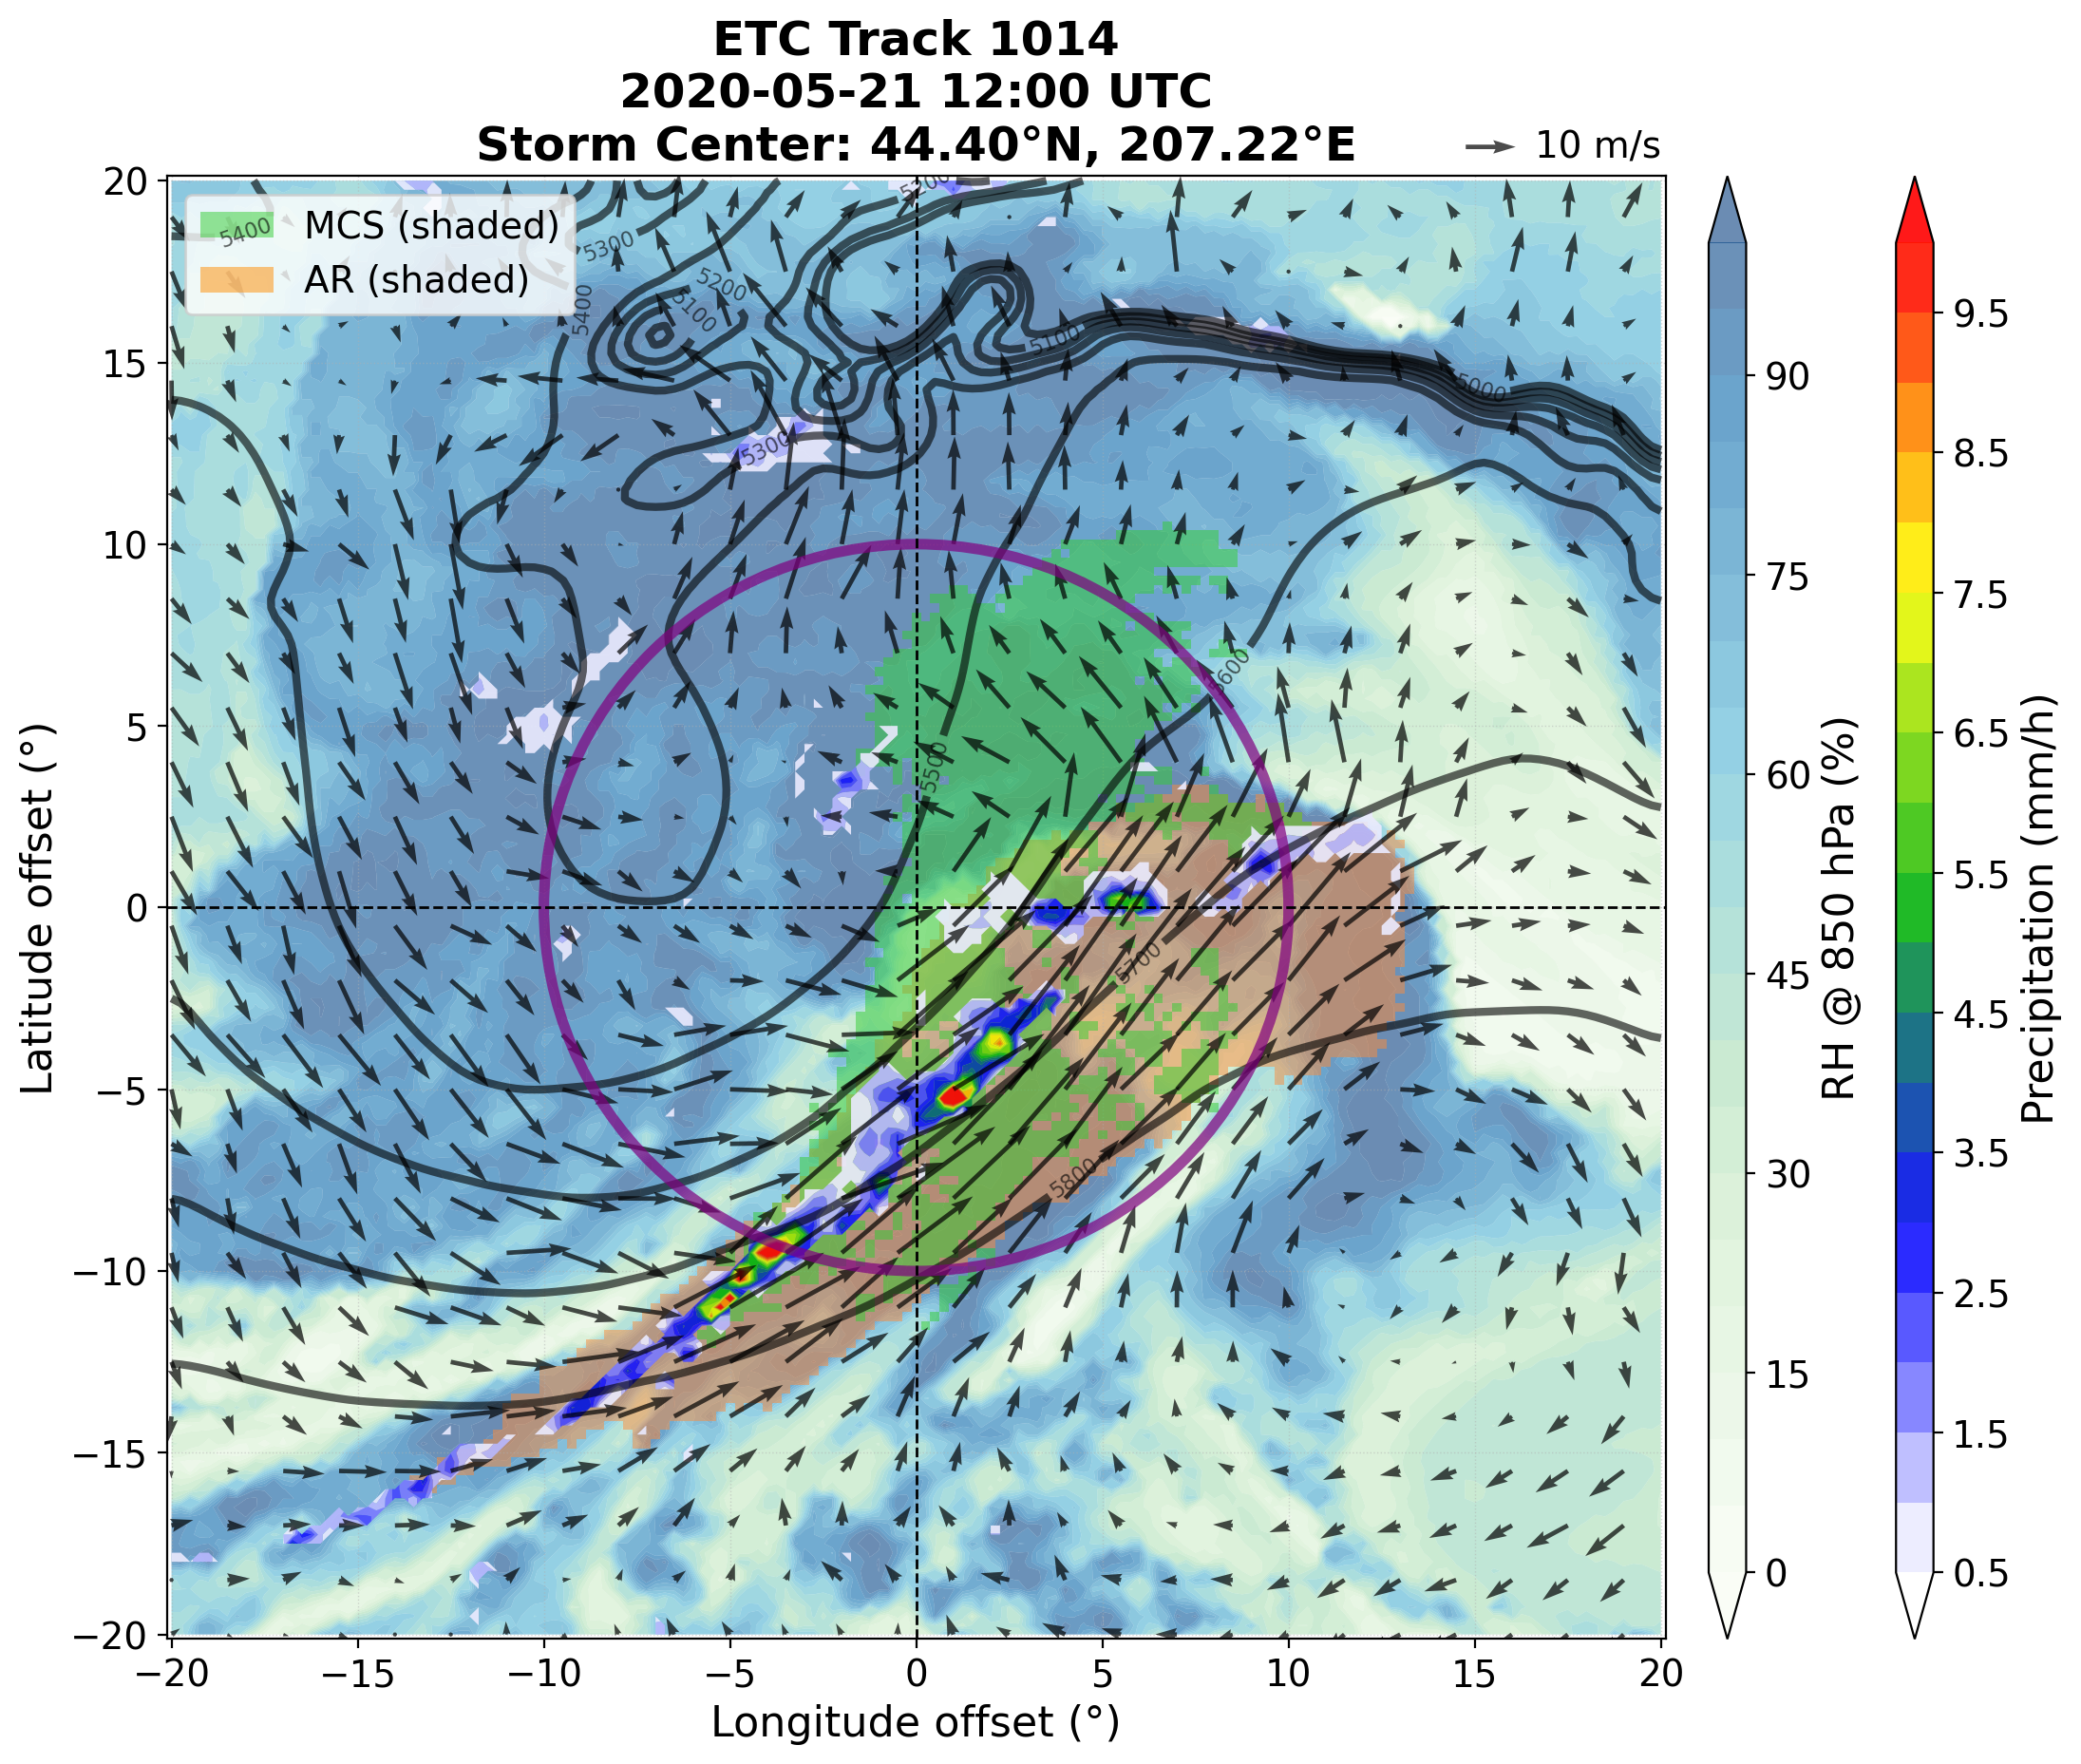

In [6]:
# Select a time index to plot (e.g., middle of the time series)
# time_idx = len(ds.time) // 2
time_idx = 3

print(f"Plotting time index: {time_idx} / {len(ds.time)}")
fig_Timestamp = pd.Timestamp(ds.time.values[time_idx])
print(f"Timestamp: {fig_Timestamp}")
time_str = fig_Timestamp.strftime("%Y%m%d_%H%M")

# figsize = None
figname = f"{figdir}etc_{time_str}.png"

# Create the plot with default settings
# - shade_alpha: Control transparency of shaded variable (0=transparent, 1=opaque)
# - shade_scale: Use 100 to convert fraction (0-1) to percentage (0-100) if needed
# - contour_smooth: Use 2-5 for moderate smoothing of contour lines
# - mcs_mask_outline=False: Use pcolormesh shading instead of outlines (limegreen color)
# - ar_mask_outline=False: Use pcolormesh shading instead of outlines
# - xlim, ylim: Set axis limits in degrees (e.g., (-15, 15))
# - xlabel, ylabel: Custom axis labels
# - shade_label, shade_label2: Custom colorbar labels
fig = plot_etc_snapshot(
    ds, 
    time_idx=time_idx,
    shade_var='rh850',
    shade_levels=np.arange(0, 101, 5),  # 0-100% in 5% intervals
    shade_cmap='GnBu',
    shade_scale=100.0,  # Convert to percentage
    shade_alpha=0.6,  # Semi-transparent
    shade_label='RH @ 850 hPa (%)',  # Custom colorbar label
    shade_var2='pr', 
    shade_levels2=np.arange(0.5, 10.1, 0.5), 
    shade_cmap2=cmaps.WhBlGrYeRe,
    shade_scale2=3600000,
    shade_alpha2=0.9,
    shade_label2='Precipitation (mm/h)',  # Custom colorbar label
    contour_var='zg500',
    contour_levels=np.arange(5000, 6400, 100),
    contour_smooth=2,
    contour_lw=3,
    u_var='ua850',
    v_var='va850',
    vector_skip=6,
    plot_mcs_mask=True,
    mcs_mask_outline=False,  # Use shading instead of outlines
    mcs_mask_alpha=0.5,      # Semi-transparent
    plot_ar_mask=True,
    ar_mask_outline=False,   # Use shading instead of outlines
    ar_mask_alpha=0.5,       # Semi-transparent
    circle_radius=10.0,
    # xlim=(-15, 15),          # Limit x-axis to ±15 degrees
    # ylim=(-15, 15),          # Limit y-axis to ±15 degrees
    xlabel='Longitude offset (°)',  # Custom x-axis label
    ylabel='Latitude offset (°)',    # Custom y-axis label
    dpi=200,
    figname=figname,
)

plt.show()


## 6. Example: Plot Multiple Time Steps

You can easily create plots for multiple time steps to see the evolution of the ETC.

In [7]:
# Plot all time steps and save each figure
n_plots = len(ds.time)
print(f"Plotting {n_plots} time steps...")

for time_idx in range(n_plots):
    # Get timestamp for this time step
    fig_Timestamp = pd.Timestamp(ds.time.values[time_idx])
    time_str = fig_Timestamp.strftime("%Y%m%d_%H%M")
    figname = f"{figdir}etc_{time_str}.png"
    
    print(f"Processing time index {time_idx+1}/{n_plots}: {fig_Timestamp}")
    
    # Create the plot with same settings as test plot
    fig = plot_etc_snapshot(
        ds, 
        time_idx=time_idx,
        shade_var='rh850',
        shade_levels=np.arange(0, 101, 5),  # 0-100% in 5% intervals
        shade_cmap='GnBu',
        shade_scale=100.0,  # Convert to percentage
        shade_alpha=0.6,  # Semi-transparent
        shade_label='RH @ 850 hPa (%)',  # Custom colorbar label
        shade_var2='pr', 
        shade_levels2=np.arange(0.5, 10.1, 0.5), 
        shade_cmap2=cmaps.WhBlGrYeRe,
        shade_scale2=3600000,
        shade_alpha2=0.9,
        shade_label2='Precipitation (mm/h)',  # Custom colorbar label
        contour_var='zg500',
        contour_levels=np.arange(5000, 6400, 100),
        contour_smooth=2,
        contour_lw=3,
        u_var='ua850',
        v_var='va850',
        vector_skip=6,
        plot_mcs_mask=True,
        mcs_mask_outline=False,  # Use shading instead of outlines
        mcs_mask_alpha=0.5,      # Semi-transparent
        plot_ar_mask=True,
        ar_mask_outline=False,   # Use shading instead of outlines
        ar_mask_alpha=0.5,       # Semi-transparent
        circle_radius=10.0,
        # xlim=(-15, 15),          # Limit x-axis to ±15 degrees
        # ylim=(-15, 15),          # Limit y-axis to ±15 degrees
        xlabel='Longitude offset (°)',  # Custom x-axis label
        ylabel='Latitude offset (°)',    # Custom y-axis label
        dpi=200,
        figname=figname,
    )
    
    # Close the figure to free memory
    plt.close(fig)

print(f"All {n_plots} figures saved to {figdir}")

Plotting 17 time steps...
Processing time index 1/17: 2020-05-20 18:00:00
Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_etc/etc_20200520_1800.png
Processing time index 2/17: 2020-05-21 00:00:00
Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_etc/etc_20200520_1800.png
Processing time index 2/17: 2020-05-21 00:00:00
Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_etc/etc_20200521_0000.png
Processing time index 3/17: 2020-05-21 06:00:00
Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_etc/etc_20200521_0000.png
Processing time index 3/17: 2020-05-21 06:00:00
Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_etc/etc_20200521_0600.png
Processing time index 4/17: 2020-05-21 12:00:00
Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_etc/etc_20200521_0600.png
Processing time index 4/17: 2020-05-21 12:00:00
Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_etc/etc_20200521_1200.png
Processing time index 5/17: 2020-05-

## 7. Summary

This notebook demonstrates:

1. **Reading combined ETC zarr data** with multiple variables
2. **Flexible plotting function** that supports:
   - Customizable shaded variable with color levels and **scale factor**
   - **Smooth shading without contour lines** using contourf with linewidths=0
   - Customizable contour variable (black lines) with **smoothing option**
   - Wind/IVT vector overlays with adjustable density
   - **MCS mask**: outlines (multi-colored) OR pcolormesh shading (limegreen)
   - **AR mask**: outlines (dark orange) OR pcolormesh shading (orange)
   - **Coordinate system in degrees** from storm center
   - **Adjustable axis limits** (xlim, ylim) in degrees
   - **Custom labels** for axes and colorbars
   - **GridSpec layout** for optimal colorbar spacing
   - Automatic title with ETC track ID and timestamp

3. **Easy customization** - adjust variables, levels, colormaps, and vector density to create publication-quality figures

**Tips for customization:**
- Adjust `shade_levels` based on your variable's typical range
- Use `shade_scale` to convert units (e.g., 3600 for kg/m²/s → mm/hr, 100 for fraction → percentage)
- Use `shade_alpha` < 1.0 for transparency - contour lines are suppressed!
- Use `contour_smooth=2-5` for moderate smoothing of contour lines (useful for noisy fields)
- Use `vector_skip` to control vector density (higher = fewer vectors)
- Set `contour_var=None` to skip contour lines
- Use different colormaps: 'RdBu_r', 'viridis', 'YlGnBu', 'coolwarm', etc.
- Use `xlim=(-15, 15)` and `ylim=(-15, 15)` to zoom into central region

**Key Features:**
- `shade_scale`: Multiply shaded variable by this factor (default: 1.0)
  - Example: Convert precipitation from kg/m²/s to mm/hr with `shade_scale=3600`
- `shade_alpha`, `shade_alpha2`: Control transparency (0=transparent, 1=opaque)
  - **Uses contourf with linewidths=0 for smooth shading without contour lines!**
- `contour_smooth`: Apply Gaussian smoothing to contour variable (default: 0 = no smoothing)
  - Example: Use `contour_smooth=3` for smoother pressure or height contours
- `shade_var2`: Add a second shaded variable overlay with independent transparency
  - Example: RH850 base layer + precipitation overlay
- `xlim`, `ylim`: Set axis limits in degrees (e.g., `xlim=(-15, 15)`)
  - Useful for zooming into the central region near the storm center
- `xlabel`, `ylabel`: Custom axis labels (default: auto-generated)
  - Example: `xlabel='Longitude offset (°)'`, `ylabel='Latitude offset (°)'`
- `shade_label`, `shade_label2`: Custom colorbar labels (default: auto-generated)
  - Example: `shade_label='RH @ 850 hPa (%)'`, `shade_label2='Precipitation (mm/h)'`

**Layout Improvements:**
- **GridSpec layout**: Automatically creates optimal spacing for colorbars
- **Minimal gaps**: Uses `wspace=0.05` to reduce space between plot and colorbars
- **No overlap**: Colorbars are in dedicated subplots, preventing overlap with plot area
- **Clean appearance**: No need for `tight_layout()` - GridSpec handles everything

**Mask Display Options:**
- **MCS Mask**:
  - `mcs_mask_outline=True`: Multi-colored contour outlines (traditional)
  - `mcs_mask_outline=False`: Limegreen pcolormesh shading with `mcs_mask_alpha` transparency
- **AR Mask**:
  - `ar_mask_outline=True`: Dark orange contour outline (traditional)
  - `ar_mask_outline=False`: Orange pcolormesh shading with `ar_mask_alpha` transparency

**Z-order (bottom to top):**
- 0: shade_var (base shaded field)
- 1: AR mask
- 2: MCS mask
- 3: shade_var2 (overlay shaded field)
- 4: Contour lines
- 5: Wind vectors

**Coordinate System:**
- X and Y axes are in degrees from the storm center
- Grid resolution read from dataset attributes (`lat_res`, `lon_res`, default: 0.25°)
